# Looking at PUSH data and running it through a detector

In [1]:
import astropy.units as u
import numpy as np

from snewpy.models import ccsn
from snewpy.flavor_transformation import AdiabaticMSW
from snewpy.neutrino import MixingParameters
from snewpy.models.base import PinchedModel, SupernovaModel

## Some plotting functions

In [3]:
import pylab as plt

In [4]:
def plot_quantity(x:u.Quantity, y:u.Quantity, xlabel=None, ylabel=None, **kwargs):
    """Plot the X vs Y array, with given axis labels, adding units"""

    #just in case we are passed bare np.arrays iwthout units
    x = u.Quantity(x)
    y = u.Quantity(y)
    
    if(len(x)==len(y)):
        plt.plot(x.value,y.value,**kwargs)
    else:
        plt.stairs(edges=x.value,values=y.value,**kwargs)
    if xlabel is not None:
        if(not x.unit.is_unity()):
            xlabel+=', '+x.unit._repr_latex_()
        plt.xlabel(xlabel)
    if ylabel is not None:
        if(not y.unit.is_unity()):
            ylabel+=', '+y.unit._repr_latex_()
        plt.ylabel(ylabel)
        
def plot_rate(rate, axis:str='time', **kwargs):
    if axis=='time':
        x = rate.time.to('s')
        y = rate.integrate_or_sum('energy').array.squeeze()
    elif axis=='energy':
        x = rate.energy.to('MeV')
        y = rate.integrate_or_sum('time').array.squeeze()
    else: 
        raise ValueError(f'axis="{axis}" should be one of "time","energy"')
    plot_quantity(x,y,xlabel=axis.capitalize(), ylabel='Event rate', **kwargs)


In [5]:
#a helper function to calculate total rate
from snewpy.flux import Container
def sum_rates(rates:list):
    res = sum([rate.array for rate in rates])
    rate = rates[0]#take first as an instance
    return Container(res,rate.flavor, rate.time, rate.energy, integrable_axes=rate._integrable_axes)

## Create the neutrino flux at Earth from the model

In [6]:
from astropy.table import Table, join

# prepare the neutrino flux from the model
model = WOLFE_2023("s27.6_SFHo_calI_Wolfe_luminosity.h5") # SN model
transformation = AdiabaticMSW(MixingParameters('NORMAL')) # Desired flavor transformation

times    = model.get_time()
energies = np.linspace(0,60,601)<<u.MeV
distance = 10*u.kpc

#get the flux from the model
flux = model.get_flux(t=times, E=energies, distance=distance, flavor_xform=transformation)
fluence = flux.integrate('time')

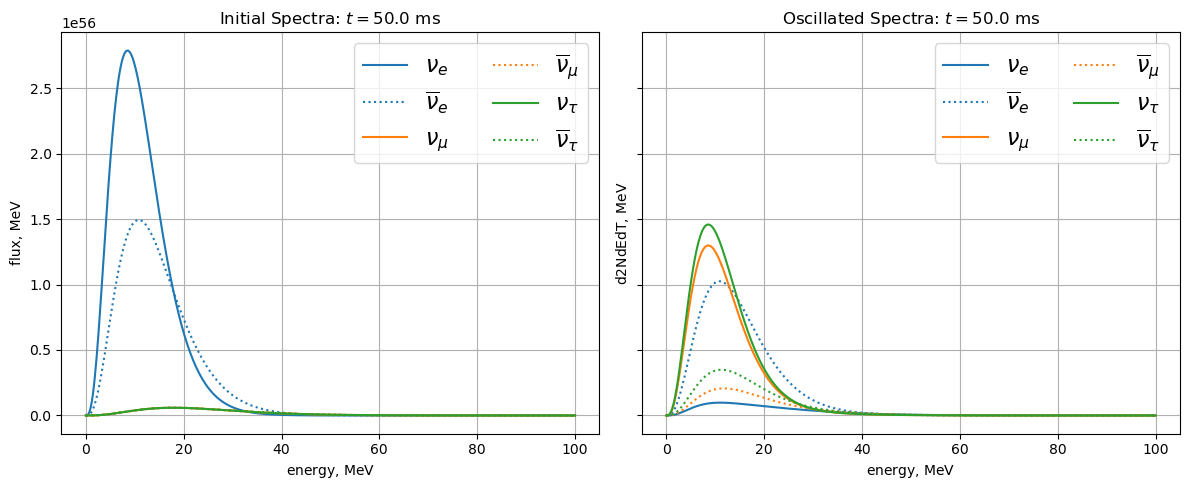

In [7]:
t = 50*u.ms

ispec = model.get_initial_spectra(t, energies)
ospec_nmo = model.get_transformed_spectra(t, energies, transformation)

fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True, tight_layout=True)

for i, spec in enumerate([ispec, ospec_nmo]):
    ax = axes[i]
    plt.sca(ax)
    spec.plot('energy')
    
    ax.set(title='Initial Spectra: $t = ${:.1f}'.format(t) if i==0 else 'Oscillated Spectra: $t = ${:.1f}'.format(t))
    ax.grid()
    ax.legend(loc='upper right', ncol=2, fontsize=16)

ax = axes[0]
ax.set(ylabel=r'flux, MeV')

fig.tight_layout();

## Using a detector config from SNOwGLoBES

In [8]:
from snewpy.rate_calculator import RateCalculator

#load the RateCalculator object
rc = RateCalculator()

Using snowglobes_data module ...


### List available detectors

In [9]:
#list available detectors
list(rc.detectors)

['wc100kt30prct',
 'wc100kt15prct',
 'ar40kt',
 'scint20kt',
 'halo1',
 'halo2',
 'novaND',
 'novaFD',
 'wc100kt30prct_he',
 'ar40kt_he',
 'icecube',
 'km3net',
 'ds20',
 'argo',
 'lz',
 'xent',
 'pandax']

### Read the detector you need

In [10]:
#read the detector
det = rc.read_detector('scint20kt')
det

C:\ProgramData\Anaconda3\Lib\site-packages\snewpy-2.0-py3.13.egg\snewpy\rate_calculator.py:388: UserWarning: Efficiency not found for detector=scint20kt, channel=ibd. Using 100% efficiency
  warn(f'Efficiency not found for detector={name}, channel={ch.name}. Using 100% efficiency')
C:\ProgramData\Anaconda3\Lib\site-packages\snewpy-2.0-py3.13.egg\snewpy\rate_calculator.py:388: UserWarning: Efficiency not found for detector=scint20kt, channel=nue_e. Using 100% efficiency
  warn(f'Efficiency not found for detector={name}, channel={ch.name}. Using 100% efficiency')
C:\ProgramData\Anaconda3\Lib\site-packages\snewpy-2.0-py3.13.egg\snewpy\rate_calculator.py:388: UserWarning: Efficiency not found for detector=scint20kt, channel=nuebar_e. Using 100% efficiency
  warn(f'Efficiency not found for detector={name}, channel={ch.name}. Using 100% efficiency')
C:\ProgramData\Anaconda3\Lib\site-packages\snewpy-2.0-py3.13.egg\snewpy\rate_calculator.py:388: UserWarning: Efficiency not found for detector=s

Detector(name="scint20kt", mass=20.0 kt, channels=['ibd', 'nue_e', 'nuebar_e', 'numu_e', 'numubar_e', 'nutau_e', 'nutaubar_e', 'nue_C12', 'nuebar_C12', 'nc_nue_C12', 'nc_nuebar_C12', 'nc_numu_C12', 'nc_numubar_C12', 'nc_nutau_C12', 'nc_nutaubar_C12', 'nue_C13', 'nc_nue_C13', 'nc_numu_C13', 'nc_nutau_C13', 'nc_nuebar_C13', 'nc_numubar_C13', 'nc_nutaubar_C13'])

### Inspecting the detector

In [11]:
#list all the channels
det.channels

{'ibd': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.1429),
 'nue_e': DetectionChannel (flavor=NU_E, smearing=True, weight=0.5716),
 'nuebar_e': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.5716),
 'numu_e': DetectionChannel (flavor=NU_MU, smearing=True, weight=0.5716),
 'numubar_e': DetectionChannel (flavor=NU_MU_BAR, smearing=True, weight=0.5716),
 'nutau_e': DetectionChannel (flavor=NU_TAU, smearing=True, weight=0.5716),
 'nutaubar_e': DetectionChannel (flavor=NU_TAU_BAR, smearing=True, weight=0.5716),
 'nue_C12': DetectionChannel (flavor=NU_E, smearing=True, weight=0.07066404999999999),
 'nuebar_C12': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.07066404999999999),
 'nc_nue_C12': DetectionChannel (flavor=NU_E, smearing=True, weight=0.07066404999999999),
 'nc_nuebar_C12': DetectionChannel (flavor=NU_E_BAR, smearing=True, weight=0.07066404999999999),
 'nc_numu_C12': DetectionChannel (flavor=NU_MU, smearing=True, weight=0.07066404999999999),
 

### Running the rate calculation

C:\ProgramData\Anaconda3\Lib\site-packages\snewpy-2.0-py3.13.egg\snewpy\rate_calculator.py:353: RuntimeWarning: divide by zero encountered in log
  return np.interp(np.log(E)/np.log(10), xp, yp, left=0, right=0)*E*1e-38 <<u.cm**2


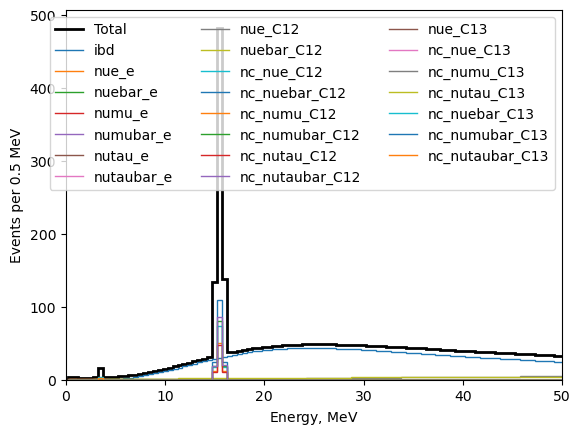

In [12]:
rates = det.run(fluence)
plot_rate(sum_rates(list(rates.values())), axis='energy', label='Total', lw=2, color='k')
for chan,rate in rates.items():
    plot_rate(rate, axis='energy', label=chan)
#plt.yscale('log')
#plt.ylim(1e-2)
plt.legend(ncols=3)
plt.ylabel(f'Events per {rate.energy.diff()[0]<<u.MeV}')
plt.xlim(0,50)
plt.show()

In [14]:
events = rc.run(fluence, det, detector_effects=False)        
events_smeared = rc.run(fluence, det, detector_effects=True)
        
# Compute number of events in all interaction channels
total_events  = sum([chan.integrate_or_sum('energy').array.squeeze().value for chan in events.values()])        
total_events_smeared  = sum([chan.integrate_or_sum('energy').array.squeeze().value for chan in events_smeared.values()])

print("Total events in detector (with smearing):" , total_events_smeared)

AttributeError: 'Detector' object has no attribute 'startswith'